# Amazon E-Commerce Review Binary Sentiment Classification
## Introduction
This notebook implements a text sentiment analysis pipeline on Amazon product review dataset. We build a binary classification task:
- Label 1: Positive reviews (rating ≥ 4.0)
- Label 0: Negative / Neutral reviews (rating < 4.0)

### Core Pipeline Workflow
1. Raw dataset loading & standardized text preprocessing (cleaning, lemmatization, stopword filtering)
2. Exploratory Data Analysis (EDA): Word clouds & top word frequency histograms for positive/negative texts
3. TF-IDF high-dimensional text feature extraction
4. Train-Validation-Test split with stratified sampling (8:1:1 ratio)
5. 3 classical machine learning classification models:
   - Multinomial Naive Bayes
   - Linear SVM with GridSearchCV hyperparameter tuning
   - XGBoost gradient boosting classifier
6. Comprehensive evaluation: Classification report, confusion matrix comparison
7. Non-linear dimensional reduction via t-SNE for text feature visualization
8. XGBoost training loss convergence curve analysis

### Dataset Features Used:  
- `review_content`: User written product review text
- `rating`: Numeric star rating for sentiment label mapping

In [26]:
!pip install wordcloud nltk scikit-learn xgboost matplotlib seaborn

import os
import re
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP toolkit
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Machine learning modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from wordcloud import WordCloud

# Auto download required NLTK resources if missing
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Suppress redundant runtime warnings
warnings.filterwarnings('ignore')

# Matplotlib font configuration for Kaggle Linux environment
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

# Create output folder for all generated figures
os.makedirs("output_figures", exist_ok=True)

In [27]:
# Initialize lemmatizer and custom stopword set (retain "not" for sentiment logic)
lemmatizer = WordNetLemmatizer()
stop_words_set = set(stopwords.words('english'))
if "not" in stop_words_set:
    stop_words_set.remove("not")

def clean_and_lemmatize(text):
    """
    Advanced text preprocessing pipeline:
    Lowercase, remove HTML tags, filter non-alphabet characters, remove stopwords, word lemmatization
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text) # Strip leftover HTML tags from raw data
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove numbers, punctuation and special symbols
    word_list = text.split()
    # Filter stopwords & apply lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in word_list if word not in stop_words_set]
    return " ".join(cleaned_tokens)

def preprocess_dataset(file_path):
    """
    Load raw CSV, clean dataset, map star ratings to binary sentiment labels
    Return fully processed dataframe with cleaned review text & sentiment tag
    """
    print("=== Step 1: Load & Clean Kaggle Amazon Review Dataset ===")
    df = pd.read_csv(file_path)
    
    # Standardize column names (strip whitespace, lowercase)
    df.columns = df.columns.str.strip().str.lower()
    print(f"Loaded dataset columns: {df.columns.tolist()}")
    
    # Check mandatory core columns exist
    required_columns = ["review_content", "rating"]
    for col in required_columns:
        if col not in df.columns:
            raise KeyError(f"Missing mandatory column in dataset: {col}")
    
    # Drop samples with empty review or missing rating
    df = df.dropna(subset=["review_content", "rating"]).reset_index(drop=True)
    
    # Clean rating column to pure numeric values
    df["rating"] = df["rating"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    df = df.dropna(subset=["rating"]).reset_index(drop=True)
    
    # Binary sentiment mapping rule
    df["sentiment"] = df["rating"].apply(lambda x: 1 if x >= 4.0 else 0)
    
    print("Running lemmatization & text cleaning on all review content...")
    df["cleaned_content"] = df["review_content"].apply(clean_and_lemmatize)
    
    # Drop rows that become empty after full text cleaning
    df = df[df["cleaned_content"].str.strip() != ""].reset_index(drop=True)
    
    print(f"Preprocessing finished. Total valid samples: {df.shape[0]}")
    print("\nSentiment class distribution (0=Negative/Neutral, 1=Positive):")
    print(df["sentiment"].value_counts())
    return df

In [28]:
import glob
# Recursively search amazon.csv under all input directories
csv_list = glob.glob("/kaggle/input/**/amazon.csv", recursive=True)

# Get the real full file path
DATA_FILE_PATH = csv_list[0]
print(f"Successfully located dataset file: {DATA_FILE_PATH}")

# Run preprocessing
df_processed = preprocess_dataset(DATA_FILE_PATH)

Successfully located dataset file: /kaggle/input/datasets/karkavelrajaj/amazon-sales-dataset/amazon.csv
=== Step 1: Load & Clean Kaggle Amazon Review Dataset ===
Loaded dataset columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']
Running lemmatization & text cleaning on all review content...
Preprocessing finished. Total valid samples: 1464

Sentiment class distribution (0=Negative/Neutral, 1=Positive):
sentiment
1    1110
0     354
Name: count, dtype: int64



=== Step 2: Run Exploratory Text Data Analysis ===


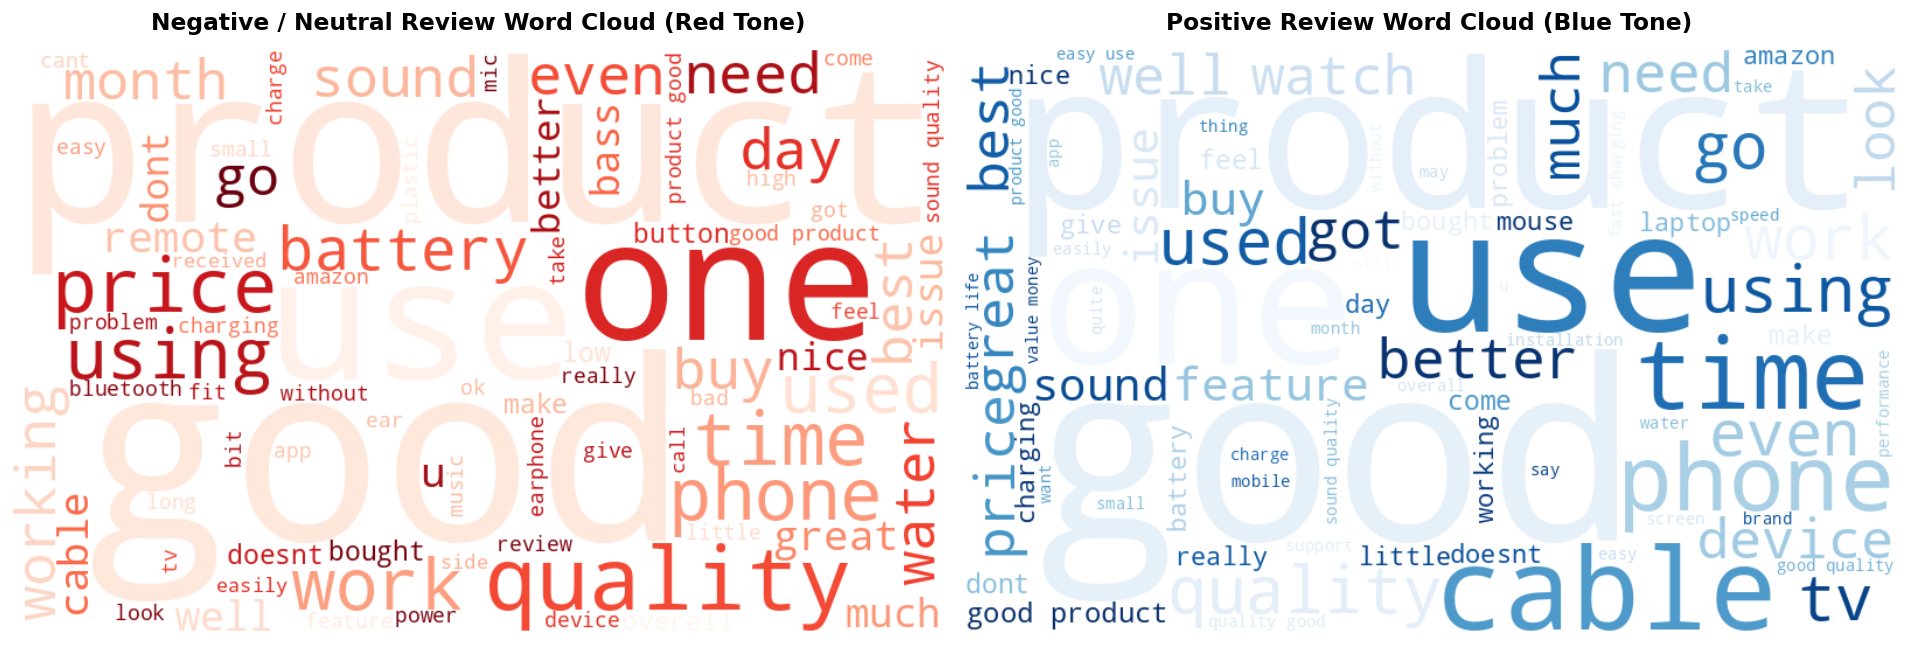

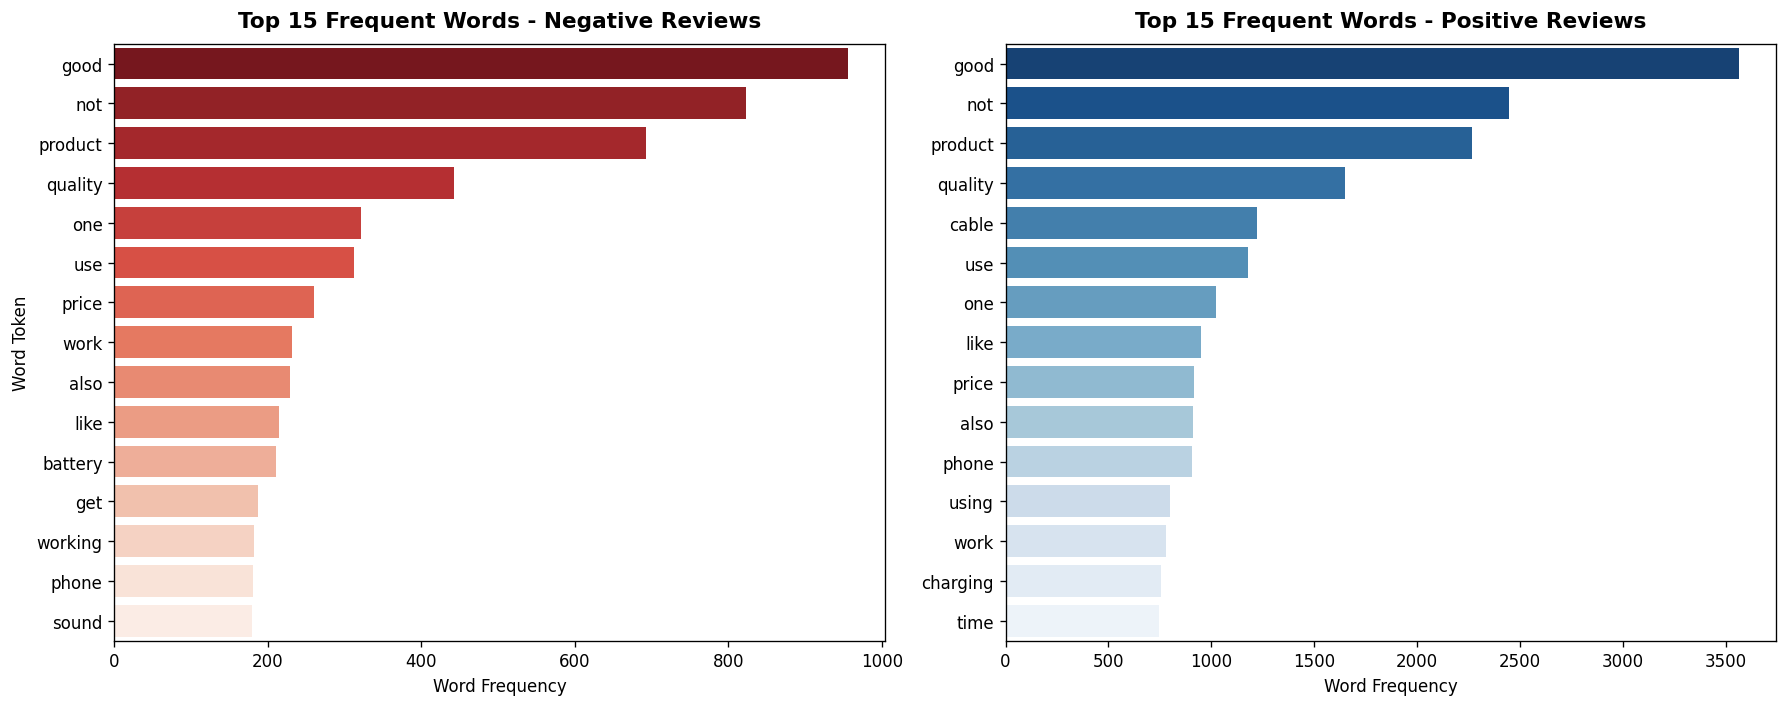

EDA figures saved to: output_figures/sentiment_wordcloud.png, output_figures/top_word_frequency.png


In [29]:
def plot_text_eda(df):
    """
    Generate two EDA visualizations:
    1. Word cloud for positive vs negative reviews
    2. Top 15 high-frequency word bar charts
    """
    print("\n=== Step 2: Run Exploratory Text Data Analysis ===")
    # Split text by sentiment class
    negative_text_all = " ".join(df[df["sentiment"] == 0]["cleaned_content"])
    positive_text_all = " ".join(df[df["sentiment"] == 1]["cleaned_content"])

    # Count top frequent words
    neg_word_freq = Counter(negative_text_all.split()).most_common(15)
    pos_word_freq = Counter(positive_text_all.split()).most_common()[:15]
    df_neg_words = pd.DataFrame(neg_word_freq, columns=["Word", "Frequency"])
    df_pos_words = pd.DataFrame(pos_word_freq, columns=["Word", "Frequency"])

    # Plot dual word cloud
    wc_negative = WordCloud(width=800, height=500, background_color="white", max_words=80, colormap="Reds", random_state=42)
    wc_positive = WordCloud(width=800, height=500, background_color="white", max_words=80, colormap="Blues", random_state=42)
    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 7))

    if len(negative_text_all.strip()) > 0:
        wc_negative.generate(negative_text_all)
        axes1[0].imshow(wc_negative, interpolation="bilinear")
        axes1[0].set_title("Negative / Neutral Review Word Cloud (Red Tone)", fontsize=14, weight="bold", pad=12)
    axes1[0].axis("off")

    if len(positive_text_all.strip()) > 0:
        wc_positive.generate(positive_text_all)
        axes1[1].imshow(wc_positive, interpolation="bilinear")
        axes1[1].set_title("Positive Review Word Cloud (Blue Tone)", fontsize=14, weight="bold", pad=12)
    axes1[1].axis("off")

    plt.tight_layout()
    wc_save_path = "output_figures/sentiment_wordcloud.png"
    plt.savefig(wc_save_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Plot top word frequency bar charts
    fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(x="Frequency", y="Word", data=df_neg_words, ax=axes2[0], palette="Reds_r")
    axes2[0].set_title("Top 15 Frequent Words - Negative Reviews", fontsize=13, weight="bold", pad=10)
    axes2[0].set_xlabel("Word Frequency")
    axes2[0].set_ylabel("Word Token")

    sns.barplot(x="Frequency", y="Word", data=df_pos_words, ax=axes2[1], palette="Blues_r")
    axes2[1].set_title("Top 15 Frequent Words - Positive Reviews", fontsize=13, weight="bold", pad=10)
    axes2[1].set_xlabel("Word Frequency")
    axes2[1].set_ylabel("")

    plt.tight_layout()
    freq_save_path = "output_figures/top_word_frequency.png"
    plt.savefig(freq_save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"EDA figures saved to: {wc_save_path}, {freq_save_path}")

# Execute EDA visualization
plot_text_eda(df_processed)

In [30]:
def prepare_text_features(df):
    """
    Split dataset into Train / Validation / Test (8:1:1 stratified split)
    Convert cleaned text into TF-IDF numerical feature matrix
    """
    print("\n=== Step 3: TF-IDF Feature Extraction & Dataset Splitting ===")
    X_raw_text = df["cleaned_content"]
    y_label = df["sentiment"]

    # First split 10% as held-out test set
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X_raw_text, y_label, test_size=0.1, random_state=42, stratify=y_label
    )
    # Split remaining 90% into train (80% full) + validation (10% full)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.1111, random_state=42, stratify=y_trainval
    )
    print(f"Dataset Split Size: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

    # Initialize TF-IDF vectorizer (unigram + bigram, top 2000 features)
    tfidf = TfidfVectorizer(max_features=2000, stop_words="english", ngram_range=(1,2))
    X_train_tfidf = tfidf.fit_transform(X_train).toarray()
    X_val_tfidf = tfidf.transform(X_val).toarray()
    X_test_tfidf = tfidf.transform(X_test).toarray()
    return X_train_tfidf, X_val_tfidf, X_test_tfidf, y_train, y_val, y_test

# Generate feature matrices and split labels
X_train, X_val, X_test, y_train, y_val, y_test = prepare_text_features(df_processed)


=== Step 3: TF-IDF Feature Extraction & Dataset Splitting ===
Dataset Split Size: Train=1170, Val=147, Test=147


In [31]:
def train_and_evaluate_all_models(X_train, X_val, X_test, y_train, y_val, y_test):
    print("\n=== Step 4: Train & Evaluate 3 Classification Models ===")
    # Combine train + validation for SVM cross-validation search
    X_cv_pool = np.vstack((X_train, X_val))
    y_cv_pool = np.concatenate((y_train, y_val))
    class_names = ["Negative/Neutral (0)", "Positive (1)"]

    # Model 1: Multinomial Naive Bayes
    print("\n[Model 1] Training Multinomial Naive Bayes")
    nb_clf = MultinomialNB(alpha=1.0)
    nb_clf.fit(X_train, y_train)
    nb_pred = nb_clf.predict(X_test)
    print("==== Naive Bayes Classification Report ====")
    print(classification_report(y_test, nb_pred, target_names=class_names, zero_division=0))

    # Model 2: Linear SVM with Grid Search Hyperparameter Tuning
    print("\n[Model 2] Running GridSearchCV for Linear SVM (3-fold CV)")
    svm_param_grid = {"C": [0.1, 1.0, 10], "kernel": ["linear"]}
    grid_search_svm = GridSearchCV(
        estimator=SVC(class_weight="balanced", random_state=42),
        param_grid=svm_param_grid,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )
    grid_search_svm.fit(X_cv_pool, y_cv_pool)
    print(f"Best SVM Hyperparameters: {grid_search_svm.best_params_}")
    svm_best = grid_search_svm.best_estimator_
    svm_pred = svm_best.predict(X_test)
    print("==== Tuned SVM Classification Report ====")
    print(classification_report(y_test, svm_pred, target_names=class_names, zero_division=0))

    # Model 3: XGBoost Gradient Boost Classifier
    print("\n[Model 3] Training XGBoost Binary Classifier")
    xgb_clf = XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
    xgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    xgb_pred = xgb_clf.predict(X_test)
    train_logloss_history = xgb_clf.evals_result()["validation_0"]["logloss"]
    print("==== XGBoost Classification Report ====")
    print(classification_report(y_test, xgb_pred, target_names=class_names, zero_division=0))

    return y_test, nb_pred, svm_pred, xgb_pred, train_logloss_history

# Run full model training pipeline
y_true_test, pred_nb, pred_svm, pred_xgb, xgb_loss_curve = train_and_evaluate_all_models(
    X_train, X_val, X_test, y_train, y_val, y_test
)


=== Step 4: Train & Evaluate 3 Classification Models ===

[Model 1] Training Multinomial Naive Bayes
==== Naive Bayes Classification Report ====
                      precision    recall  f1-score   support

Negative/Neutral (0)       1.00      0.03      0.05        36
        Positive (1)       0.76      1.00      0.86       111

            accuracy                           0.76       147
           macro avg       0.88      0.51      0.46       147
        weighted avg       0.82      0.76      0.67       147


[Model 2] Running GridSearchCV for Linear SVM (3-fold CV)
Best SVM Hyperparameters: {'C': 10, 'kernel': 'linear'}
==== Tuned SVM Classification Report ====
                      precision    recall  f1-score   support

Negative/Neutral (0)       0.58      0.61      0.59        36
        Positive (1)       0.87      0.86      0.86       111

            accuracy                           0.80       147
           macro avg       0.73      0.73      0.73       147
        we


=== Step 5: Generate Final Result Visualizations ===


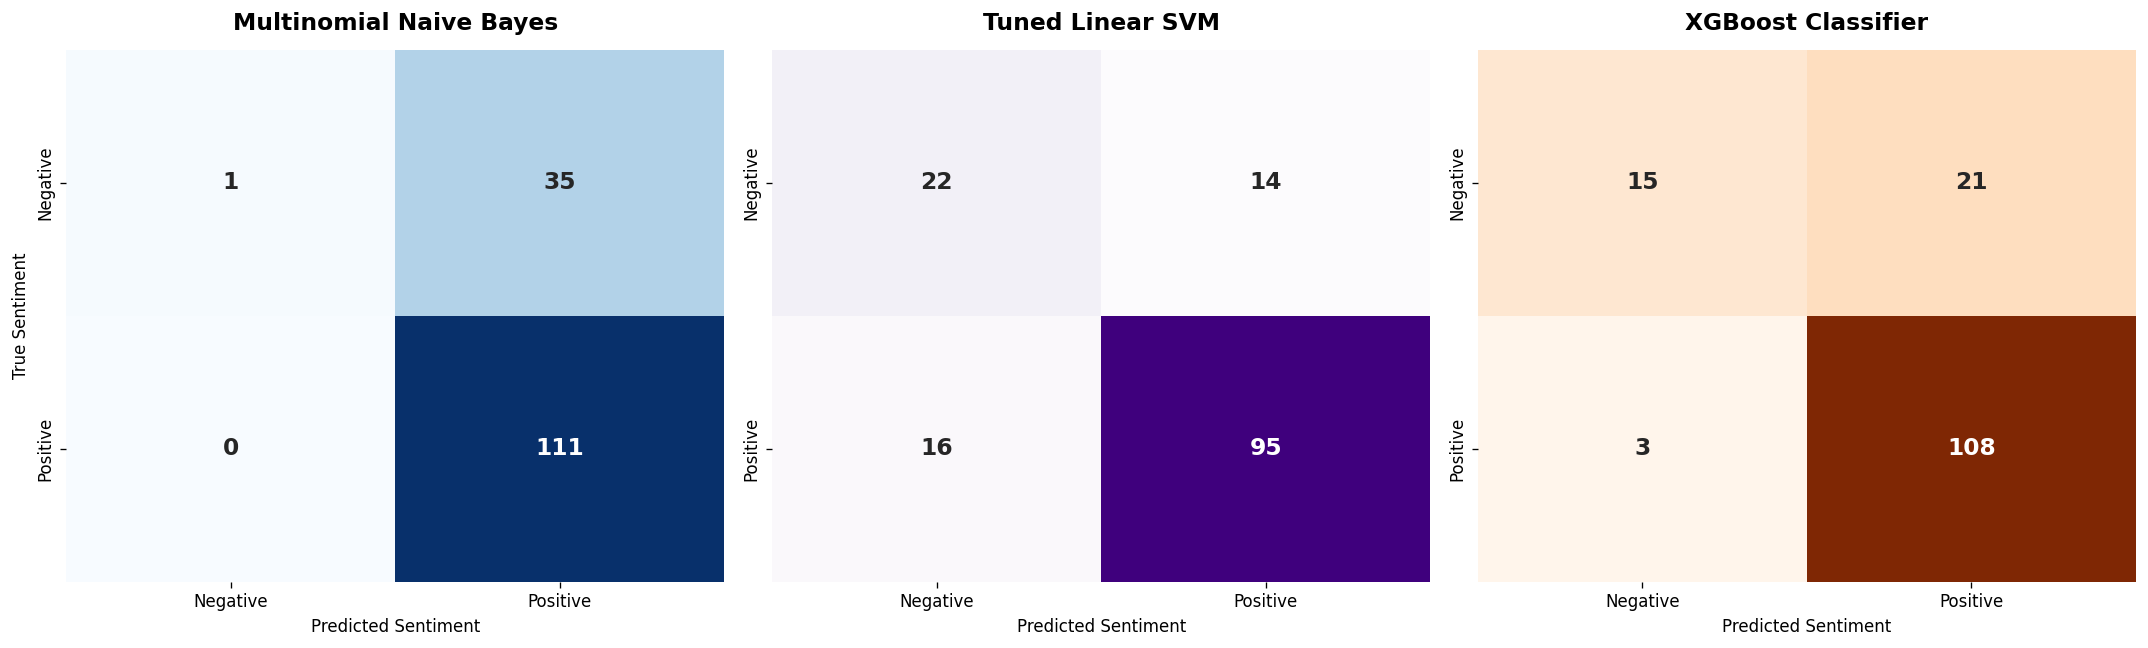

Running t-SNE dimensional reduction on test set TF-IDF features...


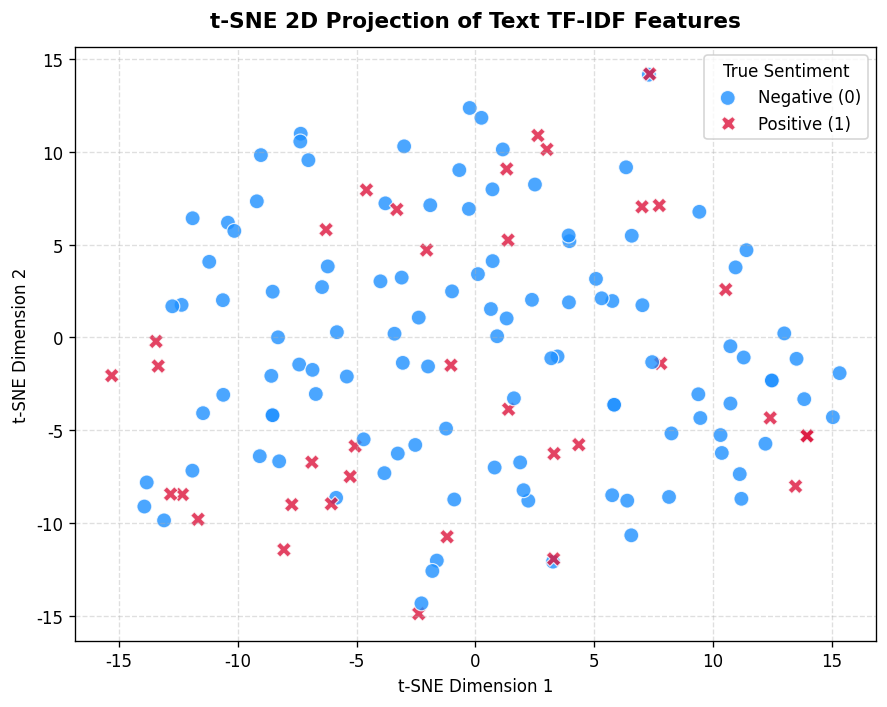

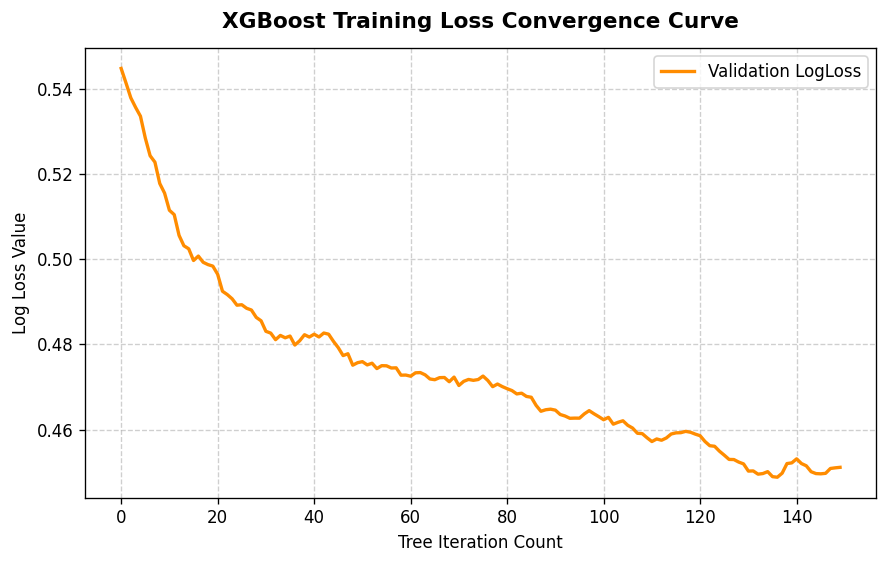

All result figures saved under ./output_figures/:
1. Confusion Matrix Comparison: output_figures/confusion_matrix_comparison.png
2. t-SNE Feature Clustering Plot: output_figures/tsne_text_clustering.png
3. XGBoost Loss Curve: output_figures/xgboost_loss_curve.png


In [32]:
def plot_final_visualizations(X_test, y_true, nb_p, svm_p, xgb_p, loss_hist):
    print("\n=== Step 5: Generate Final Result Visualizations ===")
    label_list = [0, 1]
    class_labels = ["Negative", "Positive"]

    # Plot 1: Side-by-Side Confusion Matrix for 3 Models
    fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5.5))
    model_info = [
        ("Multinomial Naive Bayes", nb_p, "Blues"),
        ("Tuned Linear SVM", svm_p, "Purples"),
        ("XGBoost Classifier", xgb_p, "Oranges")
    ]
    for idx, (title, preds, cmap) in enumerate(model_info):
        cm_matrix = confusion_matrix(y_true, preds, labels=label_list)
        sns.heatmap(
            cm_matrix, annot=True, fmt="d", cmap=cmap, ax=axes_cm[idx], cbar=False,
            xticklabels=class_labels, yticklabels=class_labels, annot_kws={"size":14, "weight":"bold"}
        )
        axes_cm[idx].set_title(title, fontsize=14, weight="bold", pad=12)
        axes_cm[idx].set_xlabel("Predicted Sentiment")
        if idx == 0:
            axes_cm[idx].set_ylabel("True Sentiment")
    plt.tight_layout()
    cm_path = "output_figures/confusion_matrix_comparison.png"
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()
    

    # Plot 2: t-SNE Non-linear Dimensional Reduction on Test TF-IDF Features
    print("Running t-SNE dimensional reduction on test set TF-IDF features...")
    tsne_transformer = TSNE(n_components=2, perplexity=min(30, len(X_test)-1), random_state=42, n_iter=1000)
    X_tsne_2d = tsne_transformer.fit_transform(X_test)
    plt.figure(figsize=(7.5, 6))
    sns.scatterplot(
        x=X_tsne_2d[:,0], y=X_tsne_2d[:,1], hue=y_true, style=y_true,
        palette=["crimson", "dodgerblue"], markers=["X", "o"], alpha=0.8, s=80
    )
    plt.title("t-SNE 2D Projection of Text TF-IDF Features", fontsize=13, weight="bold", pad=12)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="True Sentiment", labels=["Negative (0)", "Positive (1)"], loc="best")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    tsne_path = "output_figures/tsne_text_clustering.png"
    plt.savefig(tsne_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Plot3: XGBoost Validation LogLoss Convergence Curve
    plt.figure(figsize=(7.5, 4.8))
    plt.plot(loss_hist, color="darkorange", linewidth=2, label="Validation LogLoss")
    plt.title("XGBoost Training Loss Convergence Curve", fontsize=13, weight="bold", pad=12)
    plt.xlabel("Tree Iteration Count")
    plt.ylabel("Log Loss Value")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    loss_path = "output_figures/xgboost_loss_curve.png"
    plt.savefig(loss_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"All result figures saved under ./output_figures/:")
    print(f"1. Confusion Matrix Comparison: {cm_path}")
    print(f"2. t-SNE Feature Clustering Plot: {tsne_path}")
    print(f"3. XGBoost Loss Curve: {loss_path}")

# Generate all final evaluation charts
plot_final_visualizations(X_test, y_true_test, pred_nb, pred_svm, pred_xgb, xgb_loss_curve)

# Experimental Result
## Model Performance Overview 
1. Multinomial Naive Bayes
   - Accuracy: 76%
   - Critical flaw: Very low recall for negative reviews, biased toward majority positive class

2. Grid-Searched Linear SVM (C=10)
   - Accuracy: 80%
   - Balanced precision & recall across both sentiment classes, best overall stability

3. XGBoost Gradient Boosting
   - Accuracy: 81% (Highest overall accuracy)
   - Slightly weaker recall on negative samples than SVM, better positive classification performance

## Key Analysis Insights
1. Dataset Imbalance: The Amazon review dataset is heavily skewed toward positive feedback (1110 positive vs 354 negative samples), causing all models to underperform on negative sentiment recognition.
2. Text Feature Effectiveness: TF-IDF unigram+bigram features effectively capture sentiment keywords for short e-commerce reviews.
3. Model Selection Guidance:
   - Lightweight fast inference task: Multinomial Naive Bayes
   - Balanced classification priority: Tuned Linear SVM
   - Highest overall accuracy with acceptable training overhead: XGBoost
4. Visualization Findings:
   - Word clouds show distinct vocabulary differences between positive and negative product feedback
   - t-SNE projection reveals partial separation of positive/negative text feature clusters, with overlapping ambiguous neutral samples